In [1]:
subs = [
    'sub-P10',
    'sub-P12',
    'sub-P13',
    'sub-P14',
    'sub-P15',
    'sub-P16',
    'sub-P17',
    'sub-P18',
    'sub-P19',
#    'sub-P20', Unattentive
    'sub-P21',
    'sub-P22',
    'sub-P23', 
    'sub-P25',    
# #        'sub-P26', missing event file
        'sub-P27',
# #        'sub-P30', incomplete data
    'sub-P31',
    'sub-P34',
    'sub-P35',
    'sub-P36',
    'sub-P37',
    'sub-P41',
    'sub-P42',
    'sub-P43',
    'sub-P44',
    'sub-P45',
    'sub-P47',
    'sub-P48',
# #        'sub-P49',   Unattentive
    'sub-P50',  
    'sub-P51',  
                    ]

In [2]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append('..')

In [3]:
results_path = '../data/processed/rsa/order_hippocampus/group_level/all_reps/rsa_results_run2.json'
results_euclidean_path = '../data/processed/rsa/order_hippocampus_euclidean/group_level/all_reps/rsa_results_run6.json'
group_level_results_path = '../data/processed/rsa/order_hippocampus/group_level/all_reps/rsa_results_run2_group_level_permutation.json'
group_level_results_euclidean_path = '../data/processed/rsa/order_hippocampus_euclidean/group_level/all_reps/rsa_results_run6_group_level_permutation.json'
results = pd.read_json(results_path).to_dict()
results_euclidean = pd.read_json(results_euclidean_path).to_dict()
group_level_results = pd.read_json(group_level_results_path).to_dict()
group_level_results_euclidean = pd.read_json(group_level_results_euclidean_path).to_dict()

# RSA
## Main Results

Mean Spearman correlation: -0.0136 ± 0.0101


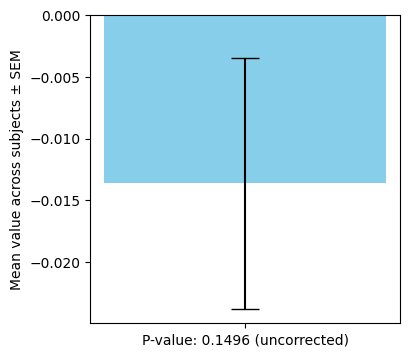

In [4]:
main_results = results['spat']
main_group_level_results = group_level_results['spatial']
# plot correlation values for euclidean and pearson
def plot_correlations(main_results, main_group_level_results):
    p_value = main_group_level_results['p_value']
    subjects = list(main_results.keys())
    spearman_values = [main_results[sub]['statistic'] for sub in subjects]
    spearman_sem = np.std(spearman_values) / np.sqrt(len(spearman_values))
    print(f"Mean Spearman correlation: {np.mean(spearman_values):.4f} ± {spearman_sem:.4f}")
    plt.figure(figsize=(4,4))
    plt.bar([0], np.mean(spearman_values), yerr=spearman_sem, capsize=10, color='skyblue')
    plt.xticks([0], [f'P-value: {p_value:.4f} (uncorrected)'])
    plt.ylabel('Mean value across subjects ± SEM')
    plt.show()
plot_correlations(main_results, main_group_level_results)

## Low and High Distances

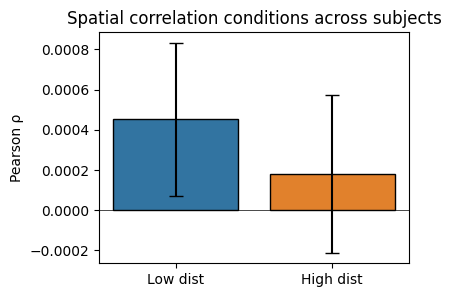

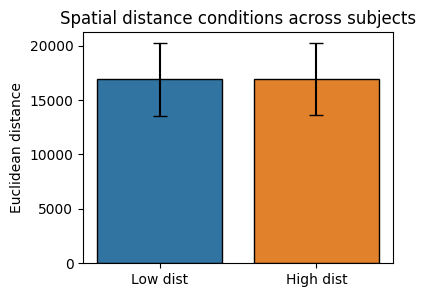

In [5]:
from scipy.stats import sem

def plot_low_and_high(results, euclidean=False):
    spat_low_corrs = results['spat_low']
    spat_high_corrs = results['spat_high']
    metric = "Euclidean distance" if euclidean else "Pearson ρ"
    value = "distance" if euclidean else "correlation"

    # --- Bar plot with SEM ---
    means = [
        np.mean(list(spat_low_corrs.values())),
        np.mean(list(spat_high_corrs.values()))
    ]
    sems = [
        sem(list(spat_low_corrs.values())),
        sem(list(spat_high_corrs.values()))
    ]

    plt.figure(figsize=(4,3))
    if not euclidean:
        plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    sns.barplot(
        x=['Low dist', 'High dist'],
        y=means,
        hue=['Low dist', 'High dist'],
        legend=False,
        capsize=0.2,
        edgecolor='black'
    )

    # Add SEM error bars manually
    plt.errorbar(
        x=[0, 1],
        y=means,
        yerr=sems,
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=1.5
    )

    plt.ylabel(metric)
    plt.title(f'Spatial {value} conditions across subjects')
    plt.show()

plot_low_and_high(results)
plot_low_and_high(results_euclidean, euclidean=True)

Mean Spearman correlation: 0.0000 ± 0.0176


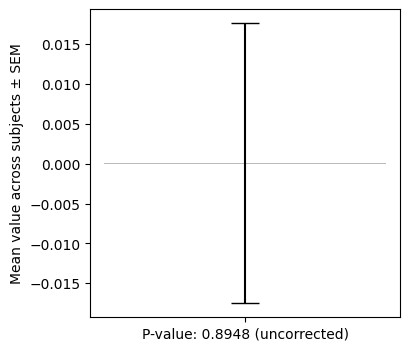

In [6]:
plot_correlations(results_euclidean['spat'], group_level_results_euclidean['spatial'])

## Positive and Negative Effect

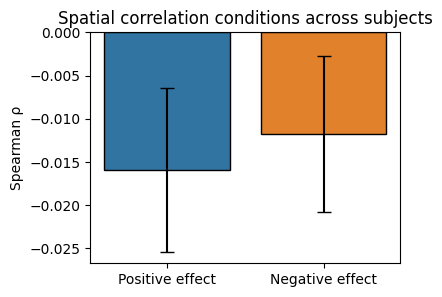

In [7]:
def plot_pos_and_low(results):
    pos_spat = [results['pos_spat'][sub]['statistic'] for sub in results['pos_spat']]
    neg_spat = [results['neg_spat'][sub]['statistic'] for sub in results['neg_spat']]
    
    # --- Bar plot with SEM ---
    means = [
        np.mean(list(pos_spat)),
        np.mean(list(neg_spat))
    ]
    sems = [
        sem(list(pos_spat)),
        sem(list(neg_spat))
    ]

    plt.figure(figsize=(4,3))
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)

    sns.barplot(
        x=['Positive effect', 'Negative effect'],
        y=means,
        hue=['Positive effect', 'Negative effect'],
        legend=False,
        capsize=0.2,
        edgecolor='black'
    )

    # Add SEM error bars manually
    plt.errorbar(
        x=[0, 1],
        y=means,
        yerr=sems,
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=1.5
    )

    plt.ylabel("Spearman ρ")
    plt.title(f'Spatial correlation conditions across subjects')
    plt.show()

plot_pos_and_low(results)


/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

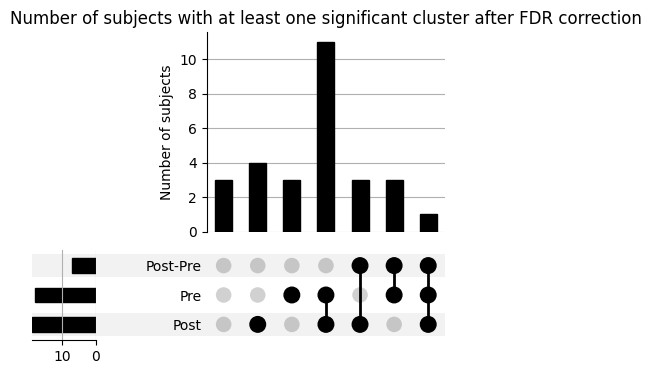

In [8]:
import pandas as pd
old_vs_new_df = pd.DataFrame({
    'Subject': subs,
    'Pre': 0,
    'Post': 0,
    'Post-Pre': 0
})
old_vs_new_df.iloc[0] = ['sub-P10', 0, 1, 1]
old_vs_new_df.iloc[1] = ['sub-P12', 1, 0, 1]
old_vs_new_df.iloc[2] = ['sub-P13', 1, 1, 0]
old_vs_new_df.iloc[3] = ['sub-P14', 1, 0, 0]
old_vs_new_df.iloc[4] = ['sub-P15', 0, 0, 0]
old_vs_new_df.iloc[5] = ['sub-P16', 1, 1, 0]
old_vs_new_df.iloc[6] = ['sub-P17', 1, 1, 0]
old_vs_new_df.iloc[7] = ['sub-P18', 0, 1, 0]
old_vs_new_df.iloc[8] = ['sub-P19', 1, 0, 1]
old_vs_new_df.iloc[9] = ['sub-P21', 1, 0, 1]
old_vs_new_df.iloc[10] = ['sub-P22', 0, 1, 0]
old_vs_new_df.iloc[11] = ['sub-P23', 1, 1, 0]
old_vs_new_df.iloc[12] = ['sub-P25', 0, 1, 0]
old_vs_new_df.iloc[13] = ['sub-P27', 0, 0, 0]
old_vs_new_df.iloc[14] = ['sub-P31', 1, 1, 1]
old_vs_new_df.iloc[15] = ['sub-P34', 1, 1, 0]
old_vs_new_df.iloc[16] = ['sub-P35', 1, 1, 0]
old_vs_new_df.iloc[17] = ['sub-P36', 1, 1, 0]
old_vs_new_df.iloc[18] = ['sub-P37', 0, 1, 1]
old_vs_new_df.iloc[19] = ['sub-P41', 1, 1, 0]
old_vs_new_df.iloc[20] = ['sub-P42', 1, 1, 0]
old_vs_new_df.iloc[21] = ['sub-P43', 1, 0, 0]
old_vs_new_df.iloc[22] = ['sub-P44', 1, 1, 0]
old_vs_new_df.iloc[23] = ['sub-P45', 1, 1, 0]
old_vs_new_df.iloc[24] = ['sub-P47', 0, 0, 0]
old_vs_new_df.iloc[25] = ['sub-P48', 0, 1, 1]
old_vs_new_df.iloc[26] = ['sub-P50', 1, 0, 0]
old_vs_new_df.iloc[27] = ['sub-P51', 0, 1, 0]
from upsetplot import UpSet, from_indicators

upset_data = from_indicators(['Pre', 'Post', 'Post-Pre'], old_vs_new_df[['Pre', 'Post', 'Post-Pre']].astype(bool))
UpSet(upset_data, subset_size='count', sort_by='degree').plot()
plt.ylabel('Number of subjects')
plt.title('Number of subjects with at least one significant cluster after FDR correction')
plt.show()

/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

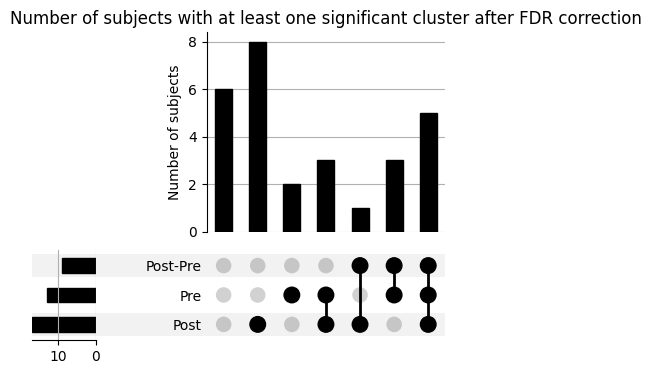

In [9]:
import pandas as pd
random_df = pd.DataFrame({
    'Subject': subs,
    'Pre': 0,
    'Post': 0,
    'Post-Pre': 0
})
random_df.iloc[0] = ['sub-P10', 0, 1, 1]
random_df.iloc[1] = ['sub-P12', 1, 1, 1]
random_df.iloc[2] = ['sub-P13', 0, 0, 0]
random_df.iloc[3] = ['sub-P14', 1, 0, 1]
random_df.iloc[4] = ['sub-P15', 0, 1, 0]
random_df.iloc[5] = ['sub-P16', 0, 1, 0]
random_df.iloc[6] = ['sub-P17', 1, 0, 0]
random_df.iloc[7] = ['sub-P18', 0, 1, 0]
random_df.iloc[8] = ['sub-P19', 0, 0, 0]
random_df.iloc[9] = ['sub-P21', 1, 0, 0]
random_df.iloc[10] = ['sub-P22', 0, 1, 0]
random_df.iloc[11] = ['sub-P23', 1, 0, 1]
random_df.iloc[12] = ['sub-P25', 0, 1, 0]
random_df.iloc[13] = ['sub-P27', 1, 1, 1]
random_df.iloc[14] = ['sub-P31', 0, 1, 0]
random_df.iloc[15] = ['sub-P34', 0, 1, 0]
random_df.iloc[16] = ['sub-P35', 0, 1, 0]
random_df.iloc[17] = ['sub-P36', 0, 0, 0]
random_df.iloc[18] = ['sub-P37', 1, 1, 1]
random_df.iloc[19] = ['sub-P41', 1, 1, 1]
random_df.iloc[20] = ['sub-P42', 1, 1, 1]
random_df.iloc[21] = ['sub-P43', 1, 0, 1]
random_df.iloc[22] = ['sub-P44', 1, 1, 0]
random_df.iloc[23] = ['sub-P45', 0, 0, 0]
random_df.iloc[24] = ['sub-P47', 0, 0, 0]
random_df.iloc[25] = ['sub-P48', 1, 1, 0]
random_df.iloc[26] = ['sub-P50', 0, 0, 0]
random_df.iloc[27] = ['sub-P51', 1, 1, 0]
from upsetplot import UpSet, from_indicators

upset_data = from_indicators(['Pre', 'Post', 'Post-Pre'], random_df[['Pre', 'Post', 'Post-Pre']].astype(bool))
UpSet(upset_data, subset_size='count', sort_by='degree').plot()
plt.ylabel('Number of subjects')
plt.title('Number of subjects with at least one significant cluster after FDR correction')
plt.show()

/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

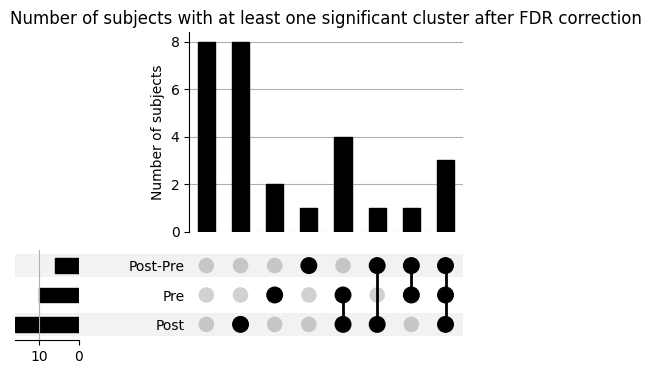

In [10]:
random_bonferroni_df = pd.DataFrame({
    'Subject': subs,
    'Pre': 0,
    'Post': 0,
    'Post-Pre': 0
})
random_bonferroni_df.iloc[0] = ['sub-P10', 0, 1, 0]
random_bonferroni_df.iloc[1] = ['sub-P12', 1, 1, 0]
random_bonferroni_df.iloc[2] = ['sub-P13', 0, 0, 0]
random_bonferroni_df.iloc[3] = ['sub-P14', 1, 0, 1]
random_bonferroni_df.iloc[4] = ['sub-P15', 0, 1, 0]
random_bonferroni_df.iloc[5] = ['sub-P16', 0, 1, 0]
random_bonferroni_df.iloc[6] = ['sub-P17', 1, 0, 0]
random_bonferroni_df.iloc[7] = ['sub-P18', 0, 1, 0]
random_bonferroni_df.iloc[8] = ['sub-P19', 0, 0, 0]
random_bonferroni_df.iloc[9] = ['sub-P21', 0, 0, 0]
random_bonferroni_df.iloc[10] = ['sub-P22', 0, 1, 0]
random_bonferroni_df.iloc[11] = ['sub-P23', 1, 0, 0]
random_bonferroni_df.iloc[12] = ['sub-P25', 0, 1, 0]
random_bonferroni_df.iloc[13] = ['sub-P27', 1, 1, 1]
random_bonferroni_df.iloc[14] = ['sub-P31', 0, 1, 0]
random_bonferroni_df.iloc[15] = ['sub-P34', 0, 0, 0]
random_bonferroni_df.iloc[16] = ['sub-P35', 0, 1, 0]
random_bonferroni_df.iloc[17] = ['sub-P36', 0, 0, 0]
random_bonferroni_df.iloc[18] = ['sub-P37', 0, 1, 1]
random_bonferroni_df.iloc[19] = ['sub-P41', 1, 1, 1]
random_bonferroni_df.iloc[20] = ['sub-P42', 1, 1, 1]
random_bonferroni_df.iloc[21] = ['sub-P43', 0, 0, 1]
random_bonferroni_df.iloc[22] = ['sub-P44', 1, 1, 0]
random_bonferroni_df.iloc[23] = ['sub-P45', 0, 0, 0]
random_bonferroni_df.iloc[24] = ['sub-P47', 0, 0, 0]
random_bonferroni_df.iloc[25] = ['sub-P48', 1, 1, 0]
random_bonferroni_df.iloc[26] = ['sub-P50', 0, 0, 0]
random_bonferroni_df.iloc[27] = ['sub-P51', 1, 1, 0]
upset_data = from_indicators(['Pre', 'Post', 'Post-Pre'], random_bonferroni_df[['Pre', 'Post', 'Post-Pre']].astype(bool))
UpSet(upset_data, subset_size='count', sort_by='degree').plot()
plt.ylabel('Number of subjects')
plt.title('Number of subjects with at least one significant cluster after FDR correction')
plt.show()

/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/boesch/miniconda3/envs/miplab_env/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

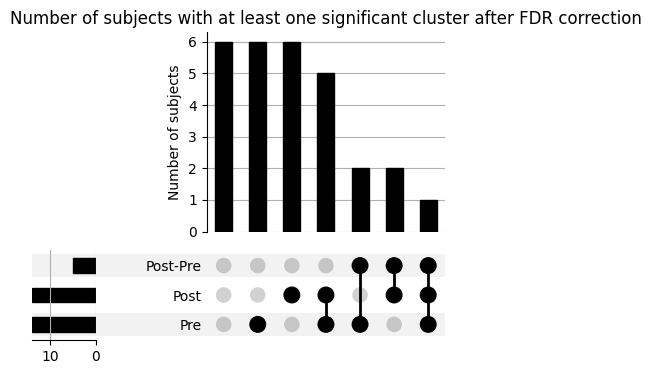

In [11]:
old_vs_new_bonferroni_df = pd.DataFrame({
    'Subject': subs,
    'Pre': 0,
    'Post': 0,
    'Post-Pre': 0
})
old_vs_new_bonferroni_df.iloc[0] = ['sub-P10', 0, 1, 1]
old_vs_new_bonferroni_df.iloc[1] = ['sub-P12', 1, 0, 0]
old_vs_new_bonferroni_df.iloc[2] = ['sub-P13', 0, 1, 0]
old_vs_new_bonferroni_df.iloc[3] = ['sub-P14', 0, 0, 0]
old_vs_new_bonferroni_df.iloc[4] = ['sub-P15', 0, 0, 0]
old_vs_new_bonferroni_df.iloc[5] = ['sub-P16', 1, 1, 0]
old_vs_new_bonferroni_df.iloc[6] = ['sub-P17', 1, 0, 0]
old_vs_new_bonferroni_df.iloc[7] = ['sub-P18', 0, 0, 0]
old_vs_new_bonferroni_df.iloc[8] = ['sub-P19', 1, 0, 1]
old_vs_new_bonferroni_df.iloc[9] = ['sub-P21', 1, 0, 1]
old_vs_new_bonferroni_df.iloc[10] = ['sub-P22', 0, 1, 0]
old_vs_new_bonferroni_df.iloc[11] = ['sub-P23', 0, 1, 0]
old_vs_new_bonferroni_df.iloc[12] = ['sub-P25', 0, 1, 0]
old_vs_new_bonferroni_df.iloc[13] = ['sub-P27', 0, 0, 0]
old_vs_new_bonferroni_df.iloc[14] = ['sub-P31', 1, 1, 0]
old_vs_new_bonferroni_df.iloc[15] = ['sub-P34', 0, 1, 0]
old_vs_new_bonferroni_df.iloc[16] = ['sub-P35', 1, 0, 0]
old_vs_new_bonferroni_df.iloc[17] = ['sub-P36', 1, 1, 0]
old_vs_new_bonferroni_df.iloc[18] = ['sub-P37', 0, 1, 1]
old_vs_new_bonferroni_df.iloc[19] = ['sub-P41', 1, 1, 1]
old_vs_new_bonferroni_df.iloc[20] = ['sub-P42', 1, 1, 0]
old_vs_new_bonferroni_df.iloc[21] = ['sub-P43', 1, 0, 0]
old_vs_new_bonferroni_df.iloc[22] = ['sub-P44', 1, 1, 0]
old_vs_new_bonferroni_df.iloc[23] = ['sub-P45', 1, 0, 0]
old_vs_new_bonferroni_df.iloc[24] = ['sub-P47', 0, 0, 0]
old_vs_new_bonferroni_df.iloc[25] = ['sub-P48', 0, 1, 0]
old_vs_new_bonferroni_df.iloc[26] = ['sub-P50', 1, 0, 0]
old_vs_new_bonferroni_df.iloc[27] = ['sub-P51', 0, 0, 0]
upset_data = from_indicators(['Pre', 'Post', 'Post-Pre'], old_vs_new_bonferroni_df[['Pre', 'Post', 'Post-Pre']].astype(bool))
UpSet(upset_data, subset_size='count', sort_by='degree').plot()
plt.ylabel('Number of subjects')
plt.title('Number of subjects with at least one significant cluster after FDR correction')
plt.show()

# Model Matrices

In [12]:
base_path = '../data/processed/rsa/order_hippocampus'
n_trials_per_sub = []
for sub in subs:
    print(f'Processing {sub}...')
    path = f'{base_path}/{sub}/{sub}_smooth_None_order_hippo__spatial_model_rdm.npy'
    matrix = np.load(path)
    n_trials = matrix.shape[0]
    n_trials_per_sub.append(n_trials)

    # further processing code here
print('Range of trials across subjects:', min(n_trials_per_sub), 'to', max(n_trials_per_sub))
print('Average number of trials across subjects:', np.mean(n_trials_per_sub))

Processing sub-P10...
Processing sub-P12...
Processing sub-P13...
Processing sub-P14...
Processing sub-P15...
Processing sub-P16...
Processing sub-P17...
Processing sub-P18...
Processing sub-P19...
Processing sub-P21...
Processing sub-P22...
Processing sub-P23...
Processing sub-P25...
Processing sub-P27...
Processing sub-P31...
Processing sub-P34...
Processing sub-P35...
Processing sub-P36...
Processing sub-P37...
Processing sub-P41...
Processing sub-P42...
Processing sub-P43...
Processing sub-P44...
Processing sub-P45...
Processing sub-P47...
Processing sub-P48...
Processing sub-P50...
Processing sub-P51...
Range of trials across subjects: 17 to 48
Average number of trials across subjects: 32.785714285714285


In [13]:
33/48

0.6875